In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib, json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

df = pd.read_csv("smart_manufacturing_data_10000.csv")
print(df.shape)
print("Data kosong:", df.isna().sum().sum(), "| Duplikat:", df.duplicated().sum())
df.head()

(10000, 13)
Data kosong: 0 | Duplikat: 0


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-09 14:06:00,45,76.36,46.28,70.25,3.13,1.75,1,0,365,Normal,0.0,0
1,2025-02-09 08:55:00,29,94.44,43.91,32.95,4.23,4.50,1,1,28,Normal,1.0,1
2,2025-01-13 09:56:00,10,66.98,64.04,63.52,2.78,2.75,0,0,499,Normal,0.0,0
3,2025-03-03 19:08:00,7,76.19,66.79,45.49,4.25,3.93,2,0,260,Normal,0.0,1
4,2025-02-24 21:54:00,46,78.14,66.23,59.70,1.69,1.62,1,0,32,Normal,0.0,0


In [2]:
FEATURES = ["temperature", "vibration", "humidity", "pressure", "energy_consumption"]
X_raw = df[FEATURES].values

scaler = StandardScaler().fit(X_raw)
X = scaler.transform(X_raw)
df[FEATURES].describe().round(2)

,temperature,vibration,humidity,pressure,energy_consumption
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,75.00,50.15,55.14,2.99,2.75
std,9.99,14.87,14.42,1.15,1.30
min,39.85,-15.83,30.00,1.00,0.50
25%,68.25,40.14,42.68,1.98,1.62
50%,75.14,50.20,55.24,3.00,2.72
75%,81.75,60.22,67.56,3.99,3.89
max,114.21,106.61,79.99,5.00,5.00


K=2  silhouette=0.150
K=3  silhouette=0.141
K=4  silhouette=0.149
K=5  silhouette=0.147
K=6  silhouette=0.146
K=7  silhouette=0.144


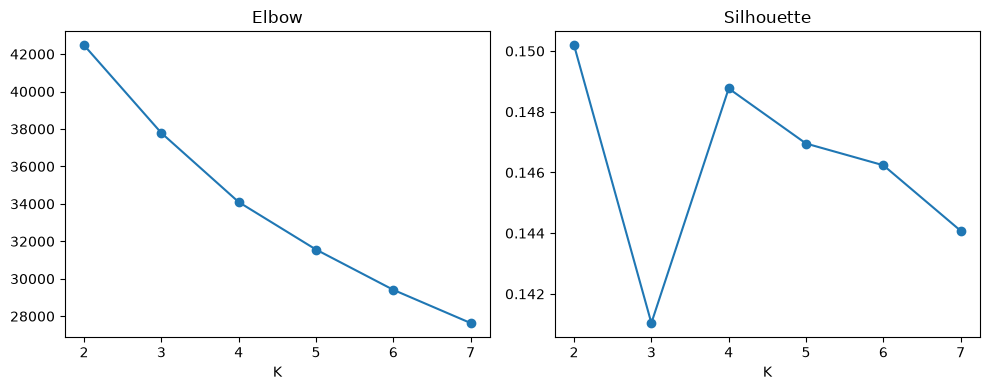

In [3]:
ks = range(2, 8)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_, sample_size=5000, random_state=42))
    print(f"K={k}  silhouette={sil[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(list(ks), inertia, "o-"); ax[0].set_title("Elbow"); ax[0].set_xlabel("K")
ax[1].plot(list(ks), sil, "o-"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("K")
plt.tight_layout(); plt.savefig("elbow_silhouette.png", dpi=150); plt.show()

In [4]:
K = 3
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X)
labels = kmeans.labels_

sil_final = silhouette_score(X, labels, sample_size=5000, random_state=42)
dbi = davies_bouldin_score(X, labels)
print(f"Silhouette: {sil_final:.3f} | Davies-Bouldin: {dbi:.3f}")

df["cluster"] = labels
profile = df.groupby("cluster")[FEATURES].mean()
profile["jumlah_data"] = df.groupby("cluster").size()
profile["persen"] = (profile["jumlah_data"] / len(df) * 100).round(1)

# Nama cluster berdasarkan rata-rata energy_consumption (rendah -> tinggi)
order = profile["energy_consumption"].sort_values().index.tolist()
cluster_names = {int(c): n for c, n in zip(order, ["Ringan", "Normal", "Berat"])}
print("Mapping:", cluster_names)

profile.index = [f"C{c} - {cluster_names[c]}" for c in profile.index]
profile.round(3)

Silhouette: 0.141 | Davies-Bouldin: 1.946
Mapping: {1: 'Ringan', 2: 'Normal', 0: 'Berat'}


,temperature,vibration,humidity,pressure,energy_consumption,jumlah_data,persen
C0 - Berat,74.848,52.235,55.359,2.324,4.013,3131,31.3
C1 - Ringan,75.586,48.422,54.317,2.202,1.594,3101,31.0
C2 - Normal,74.641,49.845,55.625,4.196,2.639,3768,37.7


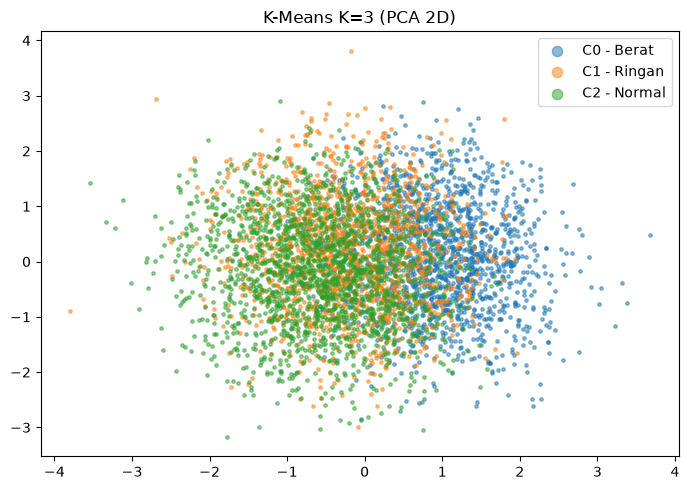

In [5]:
Z = PCA(n_components=2, random_state=42).fit_transform(X)
idx = np.random.default_rng(42).choice(len(Z), 5000, replace=False)
plt.figure(figsize=(7, 5))
for c in range(K):
    m = labels[idx] == c
    plt.scatter(Z[idx][m, 0], Z[idx][m, 1], s=6, alpha=0.5, label=f"C{c} - {cluster_names[c]}")
plt.legend(markerscale=3); plt.title("K-Means K=3 (PCA 2D)")
plt.tight_layout(); plt.savefig("cluster_pca.png", dpi=150); plt.show()

In [6]:
joblib.dump(kmeans, "model_clustering.pkl")
joblib.dump(scaler, "scaler_clustering.pkl")
meta = {"features": FEATURES, "cluster_names": {str(k): v for k, v in cluster_names.items()},
        "silhouette": float(sil_final), "davies_bouldin": float(dbi)}
json.dump(meta, open("clustering_meta.json", "w"), indent=2)

model = joblib.load("model_clustering.pkl")
sc = joblib.load("scaler_clustering.pkl")
contoh = df[FEATURES].iloc[[0]].values
cid = int(model.predict(sc.transform(contoh))[0])
print("Contoh input:", contoh[0], "->", cluster_names[cid])

Contoh input: [76.36 46.28 70.25  3.13  1.75] -> Ringan


In [7]:
import joblib, pandas as pd

clf = joblib.load("maintenance_classifier.pkl")
df = pd.read_csv("smart_manufacturing_data_10000.csv")

X = df[list(clf.feature_names_in_)]
print("Prediksi model :", clf.predict(X.iloc[:5]))
print("Jawaban asli   :", df["maintenance_required"].iloc[:5].values)

Prediksi model : [0 1 0 1 0]
Jawaban asli   : [0 1 0 1 0]
